In [2]:
import pandas as pd
import numpy as np
import janitor

from plotnine import *
from lets_plot import *

LetsPlot.setup_html()

#**Read Data using pd.read (file format)**

In [3]:
teleco_customer = pd.read_csv("C:/Users/vanth/Downloads/mini project/mini project/telco/telco_customer_churn2.csv")

teleco_customer

,customer_id,gender,senior_citizen,partner,DEPENDENTS,tenure,pho_ne_service,multi$ple_l@ines,int#e&rnet_service,onli!ne_secur^ity,...,device_protectio+n,TECH_SUP(PORT,st-rea(min(g_tv,streaming_movies,c!ontract,paperless_b%illing,paym#ent_*metho_d,mon^thly_char^ges,t-otal_c(harges,ch_u+rn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7743,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7744,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7745,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7746,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


Before working with a dataset, there are few properties of the data you should be aware of; the columns, size and shape. You habe to check for missing values and tidy it up before visualizing.

In [4]:
teleco_customer.shape

(7748, 21)

In [5]:
teleco_customer.size

162708

In [6]:
#clean_names function to remove special characters

teleco_customer.clean_names(remove_special = True)

,customer_id,gender,senior_citizen,partner,dependents_,tenure,pho_ne_service,multiple_l_ines,internet_service,online_security,...,device_protection,tech_sup_port,st_rea_min_g_tv,streaming_movies,contract,paperless_billing,payment_metho_d,monthly_charges,t_otal_c_harges_,ch_urn_
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7743,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7744,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7745,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7746,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [7]:
# Quick and dirty approach for small datasets:
teleco_customer.columns = [
    "customer_id", "gender", "senior_citizen", "partner", "dependents",
    "tenure", "phone_service", "multiple_lines", "internet_service",
    "online_security", "online_backup", "device_protection", "tech_support",
    "streaming_tv", "streaming_movies", "contract", "paperless_billing",
    "payment_method", "monthly_charges", "total_charges", "churn"
]

teleco_customer.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [8]:
teleco_customer.isna()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7743,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7744,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7745,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7746,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
teleco_customer.isna().sum()

customer_id           0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn                 0
dtype: int64

In [10]:
#quick recheck to confirm the headers were changed
teleco_customer.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [11]:
# Check if categorical values are consistent
for col in ["phone_service", "multiple_lines", "online_security"]:
    print(f"\nColumn: {col}")
    print(f"Unique values: {teleco_customer[col].unique()}")
    print(f"Number of unique values: {teleco_customer[col].nunique()}")


Column: phone_service
Unique values: ['No' 'Yes']
Number of unique values: 2

Column: multiple_lines
Unique values: ['No phone service' 'No' 'Yes']
Number of unique values: 3

Column: online_security
Unique values: ['No' 'Yes' 'No internet service']
Number of unique values: 3


In [12]:
# Clean all three columns at once


for col in ["phone_service", "multiple_lines", "online_security"]:
    teleco_customer[col] = teleco_customer[col].replace({
        "No phone service": "No",
        "No internet service": "No",
        "NO": "No",
        "no": "No",
        "YES": "Yes",
        "yes": "Yes"
    })

teleco_customer.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [17]:
# Check duplicates
print(teleco_customer['customer_id'].duplicated().sum())


705


In [18]:
# Drop duplicates based on customer_id
teleco_customer = teleco_customer.drop_duplicates(subset='customer_id', keep='first')
teleco_customer

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
5,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7743,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7744,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7745,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7746,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


VISUALIZATION

In [31]:
# FIRST create the tenure_group column
teleco_customer["tenure_group"] = pd.cut(teleco_customer["tenure"], 
                                          bins=[0, 12, 24, 48, 72, 100], 
                                          labels=["0-1 year", "1-2 years", "2-4 years", "4-6 years", "6+ years"])
teleco_customer["tenure_group"]

0        0-1 year
1       2-4 years
2        0-1 year
3       2-4 years
5        0-1 year
          ...    
7743    1-2 years
7744    4-6 years
7745     0-1 year
7746     0-1 year
7747    4-6 years
Name: tenure_group, Length: 7043, dtype: category
Categories (5, object): ['0-1 year' < '1-2 years' < '2-4 years' < '4-6 years' < '6+ years']

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

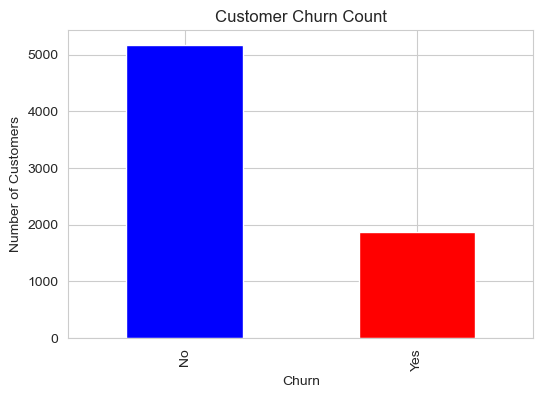

In [20]:
# Simple bar chart of churn
#: "This graph shows how many customers left the company (red bar) versus how many stayed (blue bar)
#It gives us a quick overview of the churn problem."


plt.figure(figsize=(6,4))
teleco_customer["churn"].value_counts().plot(kind = "bar", color = ["blue", "red"])
plt.title("Customer Churn Count")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

<Figure size 800x400 with 0 Axes>

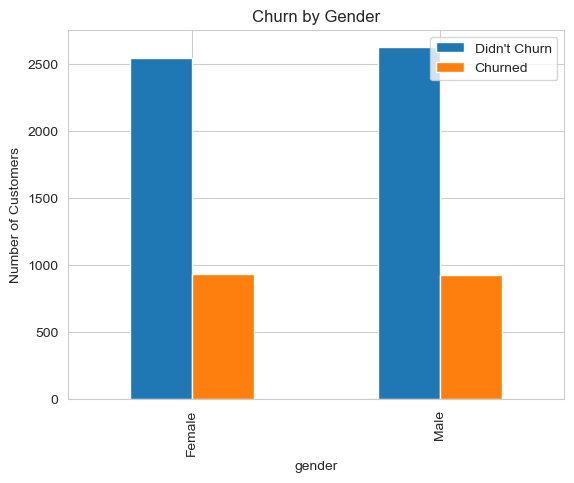

In [21]:
# Churn by gender
#This compares churn between male and female customers. We can see if gender has any effect on whether customers leave or stay.

plt.figure(figsize=(8,4))
pd.crosstab(teleco_customer["gender"], teleco_customer["churn"]).plot(kind="bar")
plt.title("Churn by Gender")
plt.ylabel("Number of Customers")
plt.legend(["Didn't Churn", "Churned"])
plt.show()

<Figure size 800x400 with 0 Axes>

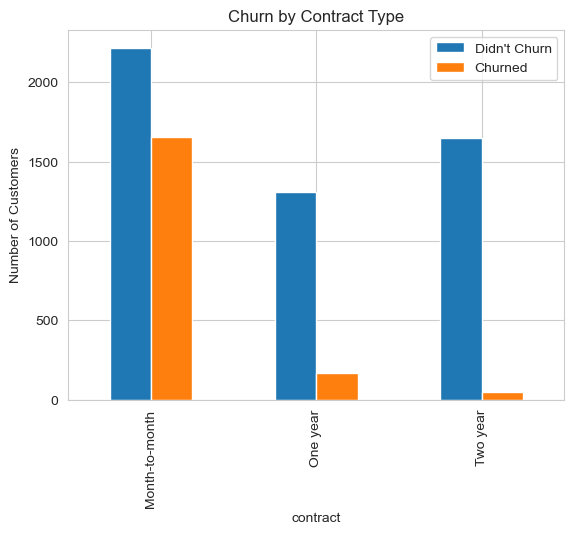

In [22]:
# Contract type vs churn
#This shows how contract length affects churn. We compare customers with month-to-month, one-year, and two-year
#contracts to see which group churns the most.

plt.figure(figsize=(8,4))
pd.crosstab(teleco_customer["contract"], teleco_customer["churn"]).plot(kind = "bar")
plt.title("Churn by Contract Type")
plt.ylabel("Number of Customers")
plt.legend(["Didn't Churn", "Churned"])
plt.show()

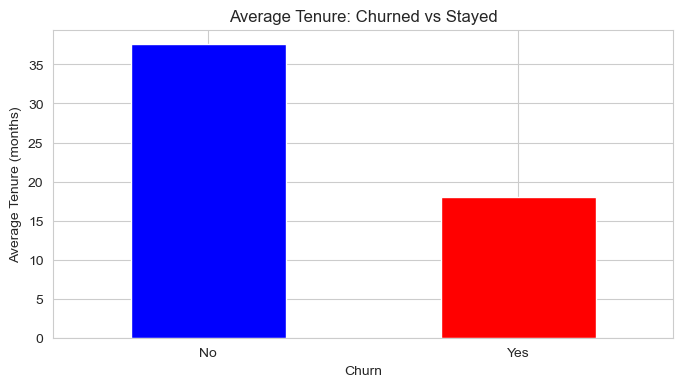

In [27]:
# Average tenure for churned vs not churned
#shows how long customers stayed before churning. The blue box shows tenure for customers who stayed, red box shows tenure for those who left. 
#We can see if new customers churn more than long-term customers

plt.figure(figsize=(8,4))
teleco_customer.groupby("churn")["tenure"].mean().plot(kind="bar", color=["blue", "red"])
plt.title("Average Tenure: Churned vs Stayed")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (months)")
plt.xticks(rotation=0)
plt.show()

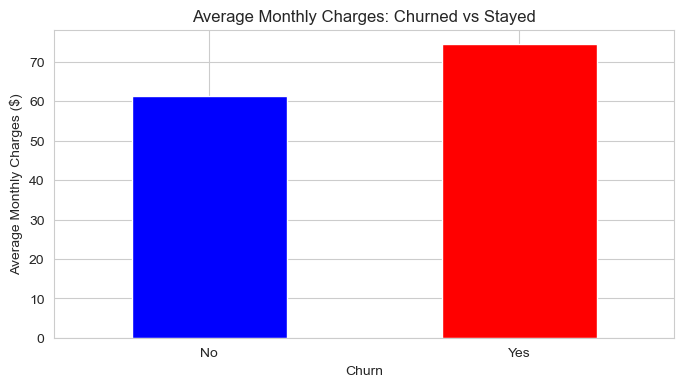

In [28]:
# Average monthly charges for churned vs not churned
#This compares monthly bills between customers who stayed versus those who left. 
#It helps us see if customers with higher bills are more likely to churn.

plt.figure(figsize=(8,4))
teleco_customer.groupby("churn")["monthly_charges"].mean().plot(kind="bar", color=["blue", "red"])
plt.title("Average Monthly Charges: Churned vs Stayed")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges ($)")
plt.xticks(rotation=0)
plt.show()

<Figure size 600x400 with 0 Axes>

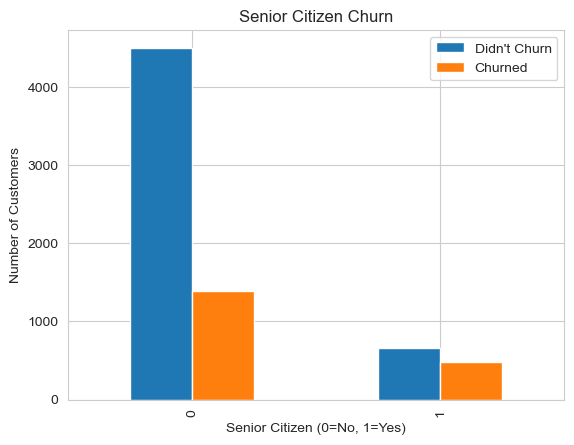

In [24]:
# Senior citizen vs churn
#This compares churn between senior citizens (1) and non-seniors (0). It shows if age group affects the decision to leave

plt.figure(figsize=(6,4))
pd.crosstab(teleco_customer["senior_citizen"], teleco_customer["churn"]).plot(kind="bar")
plt.title("Senior Citizen Churn")
plt.xlabel("Senior Citizen (0=No, 1=Yes)")
plt.ylabel("Number of Customers")
plt.legend(["Didn't Churn", "Churned"])
plt.show()

<Figure size 800x400 with 0 Axes>

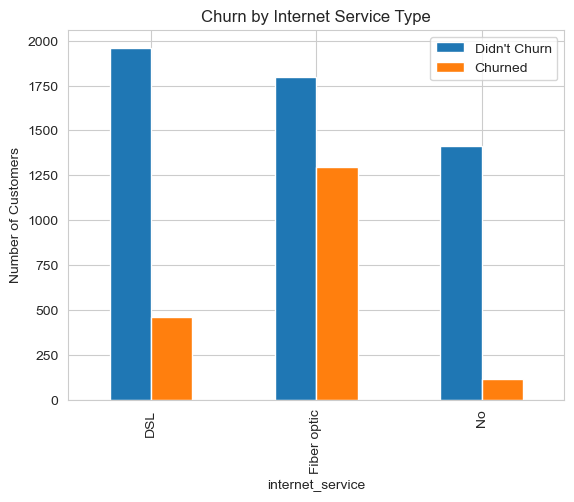

In [25]:
#This compares churn across different internet service types - DSL, Fiber optic, or No internet. 
#It shows if the type of connection affects customer loyalty

plt.figure(figsize=(8,4))
pd.crosstab(teleco_customer["internet_service"], teleco_customer["churn"]).plot(kind="bar")
plt.title("Churn by Internet Service Type")
plt.ylabel("Number of Customers")
plt.legend(["Didn't Churn", "Churned"])
plt.show()

<Figure size 1000x400 with 0 Axes>

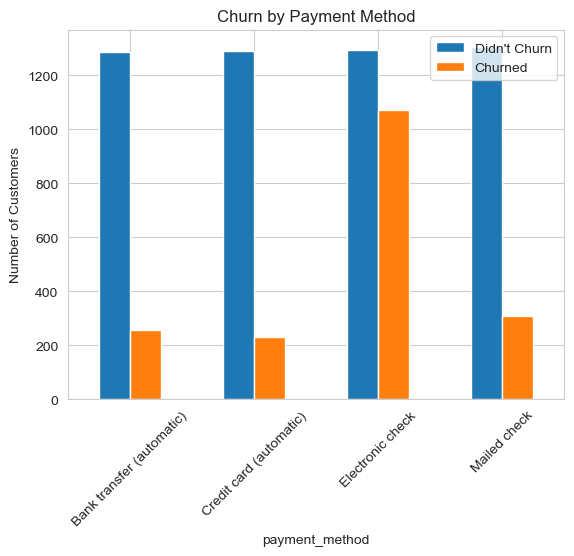

In [26]:
#This shows how payment method affects churn. We compare customers who pay by electronic check, mailed check, bank transfer, 
#or credit card to see which payment method has the highest churn

plt.figure(figsize=(10,4))
pd.crosstab(teleco_customer["payment_method"], teleco_customer["churn"]).plot(kind="bar")
plt.title("Churn by Payment Method")
plt.ylabel("Number of Customers")
plt.legend(["Didn't Churn", "Churned"])
plt.xticks(rotation=45)
plt.show()

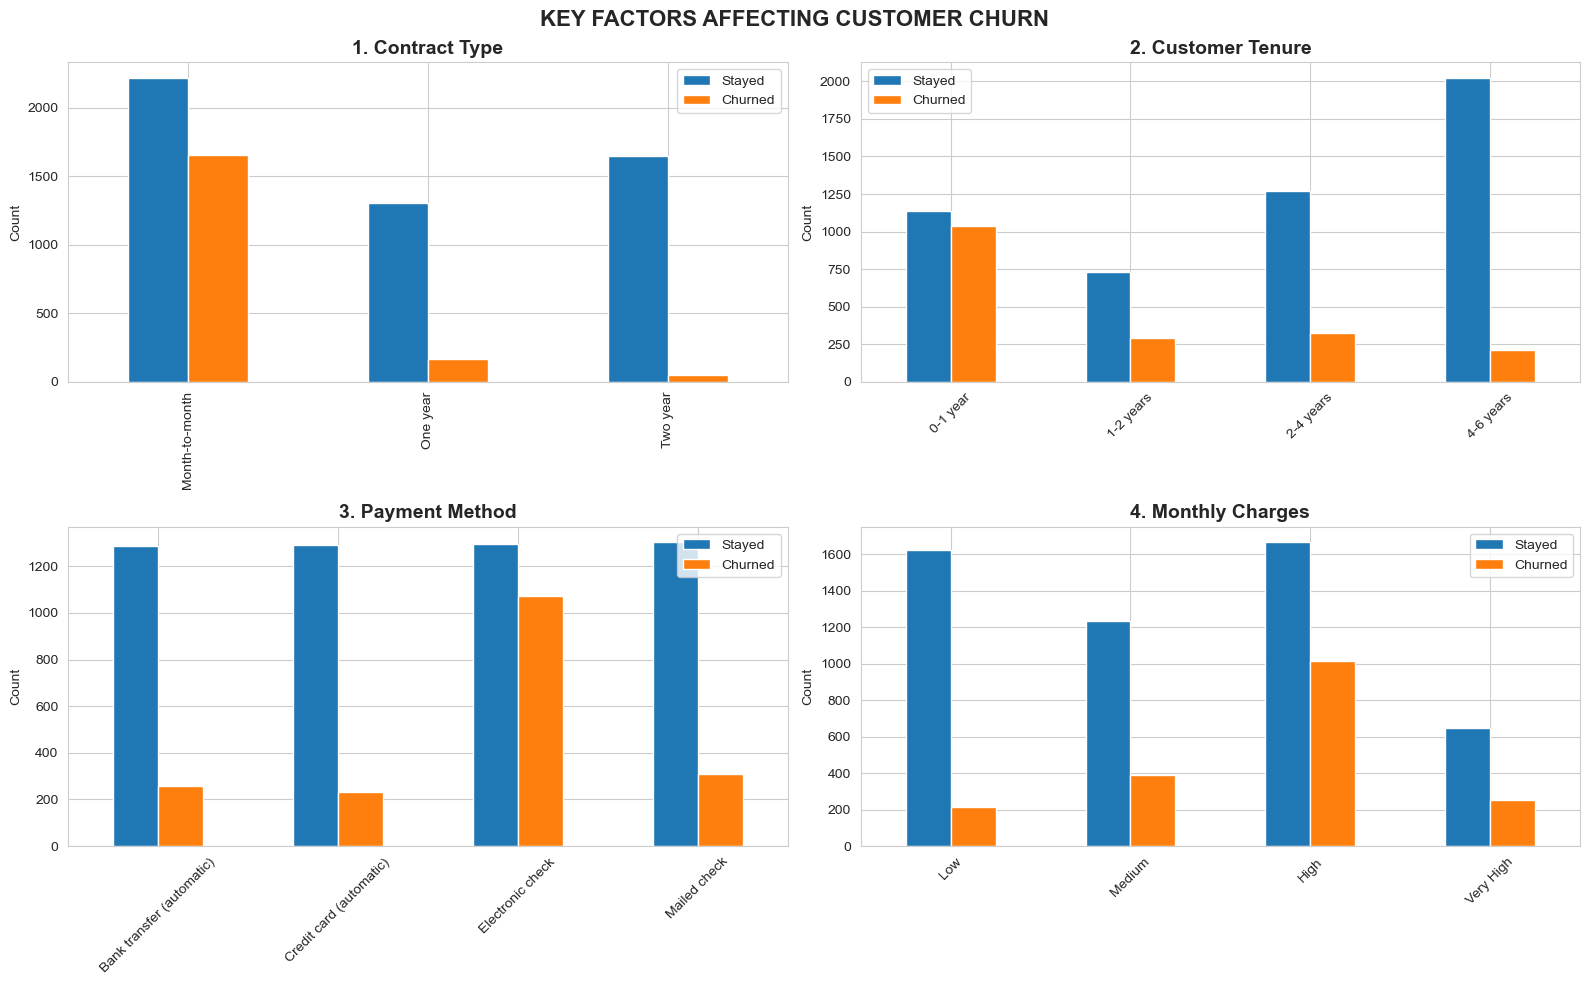

In [32]:
#Create a figure with 4 important plots
plt.figure(figsize=(16,10))

# 1. Contract (most important)
plt.subplot(2, 2, 1)
pd.crosstab(teleco_customer["contract"], teleco_customer["churn"]).plot(kind="bar", ax=plt.gca())
plt.title("1. Contract Type", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("Count")
plt.legend(["Stayed", "Churned"])

# 2. Tenure groups
plt.subplot(2, 2, 2)
pd.crosstab(teleco_customer["tenure_group"], teleco_customer["churn"]).plot(kind="bar", ax=plt.gca())
plt.title("2. Customer Tenure", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("Count")
plt.legend(["Stayed", "Churned"])
plt.xticks(rotation=45)

# 3. Payment Method
plt.subplot(2, 2, 3)
pd.crosstab(teleco_customer["payment_method"], teleco_customer["churn"]).plot(kind="bar", ax=plt.gca())
plt.title("3. Payment Method", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("Count")
plt.legend(["Stayed", "Churned"])
plt.xticks(rotation=45)

# 4. Monthly Charges (binned)
plt.subplot(2, 2, 4)
teleco_customer["price_group"] = pd.cut(teleco_customer["monthly_charges"], 
                                         bins=[0, 40, 70, 100, 150], 
                                         labels=["Low", "Medium", "High", "Very High"])
pd.crosstab(teleco_customer["price_group"], teleco_customer["churn"]).plot(kind="bar", ax=plt.gca())
plt.title("4. Monthly Charges", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("Count")
plt.legend(["Stayed", "Churned"])
plt.xticks(rotation=45)

plt.suptitle("KEY FACTORS AFFECTING CUSTOMER CHURN", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
print("=== CHURN SUMMARY ===")
print(f"Total customers: {len(teleco_customer)}")
print(f"Churned: {teleco_customer['churn'].value_counts().get('Yes', 0)}")
print(f"Churn rate: {(teleco_customer['churn'].value_counts().get('Yes', 0)/len(teleco_customer)*100):.1f}%")

=== CHURN SUMMARY ===
Total customers: 7043
Churned: 1869
Churn rate: 26.5%


In [ ]:
#The data shows a churn rate of 26.5%, meaning over a quarter of customers are leaving. 
#This is higher than the industry average and represents a significant loss in revenue. 